# Anomaly Detection models
The goal is to detect anomalies score on order-level records, compare several unsupervised approaches  and identify the most reliable method for detecting shipping and discount anomalies. The notebook also adds interpretability through anomaly types, rankings, and human-readable explanations.

The notebook focuses on:
- scoring records with multiple anomaly detection methods
- comparing model stability across seeds and parameter settings
- measuring agreement between model rankings and top detections
- selecting a production-ready threshold
- classifying anomalies by business deviation
- generating interpretable explanations for review

The final output is a ranked anomaly dataset that can be used for manual review, reporting, or deployment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

from itertools import combinations
import joblib

from pathlib import Path
from config.settings import DATA_DIR, RESULTS_FIG, RESULTS_TAB

In [2]:
warnings.filterwarnings('ignore')

data_dir = Path(DATA_DIR)
results_fig = Path(RESULTS_FIG)
results_tab = Path(RESULTS_TAB)

---
## Data loading and preparation

In [3]:
df = pd.read_parquet(data_dir / 'features_df.parquet').reset_index(drop=True)

In [4]:
# Add stable row identifier for consistent ranking
df.insert(0, 'row_id', np.arange(len(df), dtype=np.int32))

### Feature definition

Only 2 domain signals used for modeling. Other columns serve for interpretation.

In [5]:
model_features = [
    'shipping_anomaly_raw',
    'discount_anomaly_raw'
]

In [6]:
# RobustScaler minimized impact of extreme discount values
scaler = RobustScaler()
X_raw = df[model_features]
X_scaled = scaler.fit_transform(X_raw)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=model_features,
    index=df.index,
)

print('Model features:')
X_scaled_df.describe().T

Model features:


,count,mean,std,min,25%,50%,75%,max
shipping_anomaly_raw,171962.0,0.001680,0.413709,-0.500000,-0.500000,0.0,0.500000,0.500000
discount_anomaly_raw,171962.0,0.020932,0.885547,-1.333333,-0.555556,0.0,0.444444,11.999775


In [7]:
# Create percentile ranks of raw domain signals
# Used later for interpretation and business classification
df['shipping_domain_rank'] = df['shipping_anomaly_raw'].rank(
    method='average',
    pct=True,
)

df['discount_domain_rank'] = df['discount_anomaly_raw'].rank(
    method='average',
    pct=True,
)

---
# Unsupervised models

## 1. Baseline model
- Simple benchmark using maximum percentile rank of shipping and discount
- Serves as simple benchmark for comparison

In [8]:
df['baseline_score_rank'] = df[
    ['shipping_domain_rank', 'discount_domain_rank']
].max(axis=1)

## 2. Isolation Forest
- Ensemble method for isolating anomalies
- Uses multiple random seeds (42, 100, 500, 1000, 1500, 2000)
- Stabilized by averaging scores

In [9]:
# Model isolates points by randomly selecting features and split values
iforest_seeds = [42, 100, 500, 1000, 1500, 2000]
iforest_models = {}
iforest_times = {}

for seed in iforest_seeds:
    start = time.perf_counter()

    model = IsolationForest(
        n_estimators=300,
        max_samples='auto',
        contamination='auto',
        random_state=seed,
        n_jobs=-1
    )

    model.fit(X_scaled)

    # score_samples() returns negative values for anomalies
    # Negate to match convention: higher score = higher anomaly degree
    score = -model.score_samples(X_scaled)

    elapsed = time.perf_counter() - start

    iforest_models[seed] = model
    iforest_times[seed] = elapsed
    df[f'iforest_score_seed_{seed}'] = score

    print(f'Isolation Forest seed({seed}): {elapsed:.2f}s')

Isolation Forest seed(42): 4.03s
Isolation Forest seed(100): 4.03s
Isolation Forest seed(500): 4.07s
Isolation Forest seed(1000): 4.06s
Isolation Forest seed(1500): 4.29s
Isolation Forest seed(2000): 4.04s


## 3. Local Outlier Factor
- Density-based method measuring local outlier factors
- Tests multiple neighborhood sizes (k=10, 20, 30, 40, 50, 60)
- `novelty=True` allows the fitted model to score new data later

In [10]:
lof_neighbors = [10, 20, 30, 40, 50, 60]

lof_models = {}
lof_times = {}
score_95 = []

for n_neighbors in lof_neighbors:
    start = time.perf_counter()

    model = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination='auto',
        novelty=True,
        n_jobs=-1
    )

    model.fit(X_scaled)

    # negative_outlier_factor_: lower values indicate anomalies
    # negate to match convention: higher score = higher anomaly
    score = -model.negative_outlier_factor_
    
    elapsed = time.perf_counter() - start

    lof_models[n_neighbors] = model
    lof_times[n_neighbors] = elapsed
    df[f'lof_score_k_{n_neighbors}'] = score

    print(f'LOF n_neighbors({n_neighbors}): {elapsed:.2f}s')

    # Collect 95th percentile for elbow chart
    score_95.append(np.percentile(score, 95))

LOF n_neighbors(10): 2.36s
LOF n_neighbors(20): 3.05s
LOF n_neighbors(30): 3.09s
LOF n_neighbors(40): 3.36s
LOF n_neighbors(50): 2.96s
LOF n_neighbors(60): 2.65s


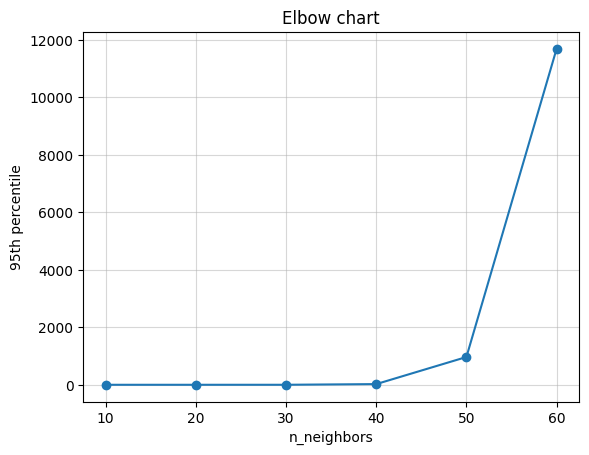

In [11]:
# Elbow chart for neighborhood selection
plt.plot(lof_neighbors, score_95, marker='o')
plt.title('Elbow chart')
plt.xlabel('n_neighbors')
plt.ylabel('95th percentile')
plt.grid(True, alpha=0.5)
plt.show()

**Interpretation:**   
The 95th percentile of LOF anomaly scores remains flat for k<40, but increases exponentially from k>=50 onwards. This clear elbow at k=50 marks the inflection point where model sensitivity substantially increases, justifying its selection as the representative model.

## 4. PCA reconstruction error
- Reduces data to 1 principal component
- Anomaly score = mean squared error between original and reconstructed

In [12]:
start = time.perf_counter()

pca_model = PCA(
    n_components=1,
    svd_solver='full'
)

X_pca = pca_model.fit_transform(X_scaled)
X_pca_reconstructed = pca_model.inverse_transform(X_pca)

# Calculate MSE for each row across both features
score = np.mean(
    (X_scaled - X_pca_reconstructed) ** 2,
    axis=1
)

pca_time = time.perf_counter() - start
df['pca_score_n_1'] = score

print(f'PCA n_components(1): {pca_time:.3f} s')
print('Explained variance ratio:', pca_model.explained_variance_ratio_)

PCA n_components(1): 0.011 s
Explained variance ratio: [0.82084525]


---
# Evaluation metrics
- In absence of ground truth, model evaluation is based on:   
    **a)** Spearman correlation between model rankings   
    **b)** Top 1% overlap using Jaccard similarity   
    **c)** Stability via mulitple seeds/parameters   
    **d)** Domain profile analysis (shipping/discount lift)

In [13]:
# Model score statistics
score_cols = [col for col in df.columns if '_score_' in col]
df[score_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
baseline_score_rank,171962.0,6.625181e-01,2.299241e-01,1.703196e-01,0.498322,0.726390,0.840665,9.999826e-01
iforest_score_seed_42,171962.0,5.009251e-01,5.800841e-02,4.387554e-01,0.460341,0.479710,0.527732,7.825769e-01
iforest_score_seed_100,171962.0,5.026259e-01,5.846930e-02,4.366782e-01,0.459994,0.481477,0.526396,7.795926e-01
iforest_score_seed_500,171962.0,5.058519e-01,5.680583e-02,4.397039e-01,0.464179,0.487440,0.529647,7.733908e-01
iforest_score_seed_1000,171962.0,5.037792e-01,5.941365e-02,4.401167e-01,0.462522,0.481379,0.529676,7.747874e-01
iforest_score_seed_1500,171962.0,5.030032e-01,5.717153e-02,4.431141e-01,0.460712,0.482198,0.522261,7.777273e-01
iforest_score_seed_2000,171962.0,5.012182e-01,5.757716e-02,4.402920e-01,0.459068,0.480105,0.522331,7.858640e-01
lof_score_k_10,171962.0,3.490521e+05,2.618953e+07,8.756925e-01,1.000000,1.000000,1.000000,4.704347e+09
lof_score_k_20,171962.0,6.871299e+05,2.030890e+07,9.227028e-01,1.000000,1.000000,1.000000,2.407007e+09
lof_score_k_30,171962.0,6.822728e+05,1.464571e+07,9.399114e-01,1.000000,1.000000,1.000000,9.119378e+08


In [14]:
# Aggregate scores from multiple model variants into single ranking
iforest_score = [col for col in df.columns if 'iforest_score' in col]
lof_score = [col for col in df.columns if 'lof_score' in col]

score_rank = pd.DataFrame(index=df.index)
score_rank['baseline'] = df['baseline_score_rank']
score_rank['iforest'] = df[iforest_score].mean(axis=1) # average across 6 seeds
score_rank['lof'] = df['lof_score_k_50']               # k=50 as representative model
score_rank['pca'] = df['pca_score_n_1']

In [15]:
score_rank

,baseline,iforest,lof,pca
0,0.922663,0.538490,1.0,0.124260
1,0.498322,0.448900,1.0,0.000001
2,0.617113,0.447427,1.0,0.000001
3,0.498322,0.537723,1.0,0.000002
4,0.752838,0.452466,1.0,0.000001
...,...,...,...,...
171957,0.828366,0.478717,1.0,0.125776
171958,0.354064,0.505408,1.0,0.125878
171959,0.271159,0.516016,1.0,0.125900
171960,0.470217,0.458822,1.0,0.125844


## a) Spearman correlation between model rankings
- Rank-based correlation measuring agreement between model predictions
- Tests whether models identify anomalies in similar order
- Heatmap displays pairwise correlations across all model variants

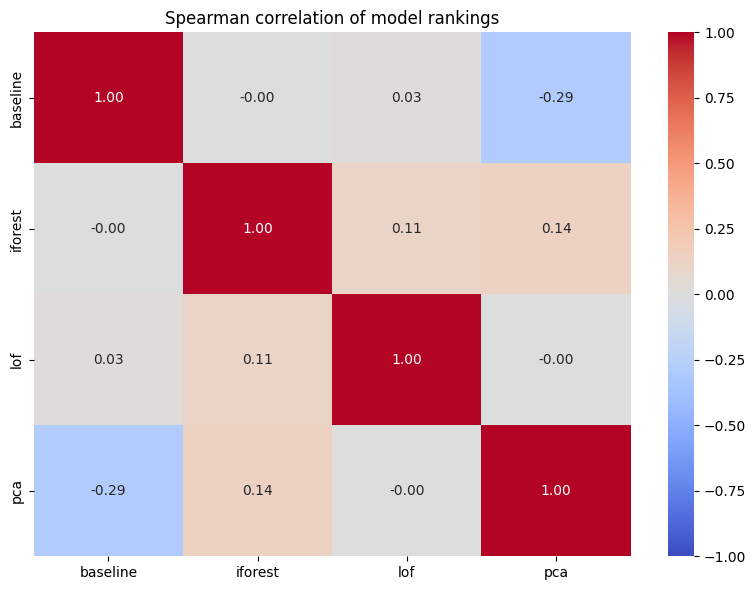

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    score_rank.corr(method='spearman'),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1
)

plt.title('Spearman correlation of model rankings')
plt.tight_layout()
plt.savefig(results_fig / 'model_rank_spearman.png', dpi=300)
plt.show()

**Interpretation:**   
Models rank anomalies by fundamentally different criteria, showing near-zero correlations across the board. Baseline and iforest (−0.00), LOF with all others (0.03−0.11), and PCA with baseline (−0.29) demonstrate that no two approaches identify anomalies in the same order

## b) Top 1% overlap using Jaccard similarity
- Identifies top 1% of flagged anomalies from each model independently
- Calculates intersection/union ratio measuring set overlap between detections
- Heatmap reveals which models agree on same top anomaly candidates

In [17]:
# Define 1% of dataset
top_n = int(np.ceil(len(df) * 0.01))

top_masks = {}
score_rank['row_id'] = np.arange(len(score_rank))

# For each model identify top 1% by highest scores
for col_name in score_rank.columns:
    top_index = (
        score_rank.sort_values(
            [col_name, 'row_id'],
            ascending=[False, True])
        .head(top_n)
        .index
    )
    
    mask = pd.Series(False, index=df.index)
    mask.loc[top_index] = True
    top_masks[col_name] = mask

In [18]:
# Jaccard matrix: overlap between top 1% sets
jaccard_matrix_overlap = pd.DataFrame(
    index=score_rank.columns,
    columns=score_rank.columns,
    dtype=float
)

for model_a in score_rank.columns:
    for model_b in score_rank.columns:
        intersection = (top_masks[model_a] & top_masks[model_b]).sum()
        union = (top_masks[model_a] | top_masks[model_b]).sum()
        jaccard_matrix_overlap.loc[model_a, model_b] = (
            intersection / union if union > 0 else np.nan)

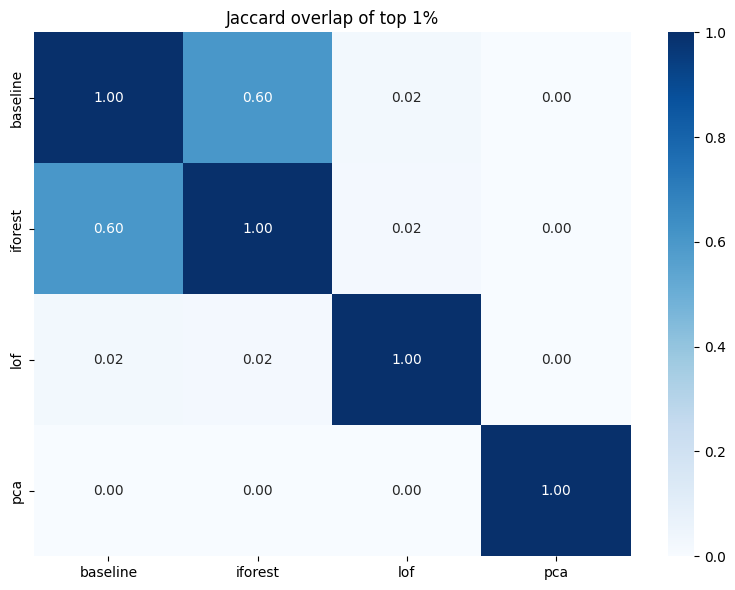

In [19]:
# Remove row_id column
jaccard_matrix_overlap.drop(index='row_id', columns='row_id', inplace= True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    jaccard_matrix_overlap,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=0, vmax=1
)

plt.title('Jaccard overlap of top 1%')
plt.tight_layout()
plt.savefig(results_fig / "model_top1_jaccard_overlap.png", dpi=300)
plt.show()

**Interpretation:**   
Baseline and iforest agree on about 60% of cases—fairly consistent. However, LOF is basically finding different records than the others (barely 2% match). PCA finds nothing that looks like what the other models found at all. 

## c) Stability via multiple seeds/parameters
- Measures consistency of top 1% selections across model variants
- Jaccard similarity averaged over all pairwise combinations within each method
- Higher stability score (closer to 1) indicates robust, parameter-independent results

In [20]:
models = {
    "Isolation Forest": iforest_score,
    "LOF": lof_score,
}

stabilities = {}

for method_name, score_cols in models.items():
    if len(score_cols) < 2:
        raise ValueError(f"Insufficient variants for {method_name} stability (need >=2).")

    # 1) For each variant, create top_n index set
    top_sets = []
    for col_name in score_cols:
        top_index = (
            df.sort_values([col_name, "row_id"], ascending=[False, True])
              .head(top_n)
              .index
        )
        top_sets.append(set(top_index))

    # 2) Average Jaccard across all pairwise combinations
    jaccard_vals = []
    for set_a, set_b in combinations(top_sets, 2):
        union = len(set_a | set_b)
        j = (len(set_a & set_b) / union) if union > 0 else np.nan
        jaccard_vals.append(j)

    stabilities[method_name] = float(np.nanmean(jaccard_vals))

# Baseline and PCA have deterministic outputs
stabilities["baseline"] = 1
stabilities["pca"] = 1

stability = pd.DataFrame.from_dict(stabilities, orient="index", columns=["stability"])
stability.to_csv(results_tab / 'model_stability.csv')
stability

,stability
Isolation Forest,0.810860
LOF,0.332709
baseline,1.000000
pca,1.000000


**Interpretation:**   
Isolation Forest's 81% cross-seed stability provides production-grade reliability (**81% of anomalies each time**).    
LOF is way less reliable—only 33% of its findings stay consistent when you tweak the neighborhood size.   
Baseline and PCA always give identical results (100% stable) because they're deterministic, but that doesn't mean they're right.

## d) Domain profile analysis (shipping/discount lift)
- Analyze shipping and discount characteristics of top 1% detections
- Compare to global averages to compute lift ratio

In [21]:
models_for_profile = ['baseline', 'iforest', 'lof', 'pca']

top_masks = {}
for col_name in models_for_profile:
    top_index = (
        score_rank.sort_values([col_name, 'row_id'],
                                    ascending=[False, True])
                      .head(top_n)
                      .index
    )
    mask = pd.Series(False, index=df.index)
    mask.loc[top_index] = True
    top_masks[col_name] = mask

# Domain profile calculation
domain_profile_rows = []

global_shipping_mean = df['shipping_anomaly_raw'].mean()
global_discount_mean = df['discount_anomaly_raw'].mean()

for model_key in models_for_profile:
    mask = top_masks[model_key]

    top_shipping_mean = df.loc[mask, 'shipping_anomaly_raw'].mean()
    top_discount_mean = df.loc[mask, 'discount_anomaly_raw'].mean()

    domain_profile_rows.append({
        'model': model_key,
        'top_n': top_n,
        'shipping_mean_top1': top_shipping_mean,
        'discount_mean_top1': top_discount_mean,
        'shipping_lift': (
            top_shipping_mean / global_shipping_mean
            if global_shipping_mean > 0 else np.nan
        ),
        'discount_lift': (
            top_discount_mean / global_discount_mean
            if global_discount_mean > 0 else np.nan
        ),
    })

domain_profile = pd.DataFrame(domain_profile_rows).set_index('model')
domain_profile.to_csv(results_tab / 'model_domain_profile.csv')
domain_profile

,top_n,shipping_mean_top1,discount_mean_top1,shipping_lift,discount_lift
model,,,,,
baseline,1720,0.511916,1.935861e+00,1.020408,3.812195e+00
iforest,1720,0.461916,1.914127e+00,0.920741,3.769396e+00
lof,1720,0.486625,6.007103e-01,0.969996,1.182949e+00
pca,1720,0.000000,1.255859e-08,0.000000,2.473101e-08


**Interpretation:**   
Baseline and iforest mainly catch shipping problems. Baseline is a bit better at catching discount anomalies too.   
LOF isn't particularly good at either—it finds anomalies but they're not really shipping or discount related.   
PCA finds almost nothing useful at all. 

**iforest is best bet for catching real business problems**

---
## Threshold determination
- Identifies minimum Isolation Forest score among top 1% detections
- This cutoff score serves as the decision boundary for production deployment
- Records with scores above threshold are flagged as anomalies (anomaly_risk = 1)

In [22]:
final_rank = score_rank.sort_values(
    ['iforest', 'row_id'],
    ascending=[False, True]
    ).index

# Reducion datasets for top 1%
top_1pct = final_rank[:top_n]

# Minimum iforest score in top 1%
score_rank_threshold = score_rank.loc[top_1pct, 'iforest'].min()

print('Number of items in top 1%:', top_n)
print('iforest_rank threshold top 1%:', score_rank_threshold.round(5))

Number of items in top 1%: 1720
iforest_rank threshold top 1%: 0.6733


In [23]:
# Flag each record if it falls within top 1%
score_rank['anomaly_risk'] = np.int8(0)
score_rank.loc[top_1pct, 'anomaly_risk'] = np.int8(1)

# Create ranking: 1 = highest anomaly, N = lowest
score_rank['anomaly_rank'] = np.empty(len(df), dtype=np.int32)
score_rank.loc[final_rank, 'anomaly_rank'] = np.arange(1, len(df) + 1, dtype=np.int32)

## Anomaly type classification
- Classify anomalies by dominant business deviation:
    - shipping
    - discount
    - mixed
- Generates human-readable explanations showing specific deviation amounts

In [24]:
shipping_rank = df['shipping_domain_rank']
discount_rank = df['discount_domain_rank']
ship_dev = df['shipping_deviation']
disc_dev = df['discount_deviation']

# Conditions for classification
both_high = (shipping_rank >= 0.80) & (discount_rank >= 0.80)
close_enough = (shipping_rank - discount_rank).abs() <= 0.15
one_high = np.maximum(shipping_rank, discount_rank) >= 0.80

mixed_condition = both_high | (close_enough & one_high)

df['anomaly_type'] = np.select(
    [mixed_condition,
    shipping_rank > discount_rank,
    discount_rank > shipping_rank],
    ['mixed', 'shipping', 'discount'],
    default='none'
)

In [25]:
# Create human-readable explanations
shipping_text = (
    'shipping '
    + ship_dev.round(2).astype(str)
    + ' days'
)

discount_text = (
    'discount '
    + (100*disc_dev).round(2).astype(str)
    + '%'
)

df['deviation_explanation'] = np.select(
    [df['anomaly_type'] == 'mixed',
     df['anomaly_type'] == 'shipping',
     df['anomaly_type'] == 'discount'],
    [shipping_text + '. ' + discount_text,
     shipping_text,
     discount_text],
    default='No dominant deviation'
)

In [26]:
# Join final model scores to main frame
df = df.join(score_rank, rsuffix='_')

In [27]:
anomaly_all = (df['anomaly_type']
    .value_counts()
    .rename('count')
    .to_frame())
anomaly_all['count_%'] = 100 * (anomaly_all['count'] / len(df))
anomaly_all.index.name = None

anomaly_top1 = (df[df['anomaly_risk'] == 1]['anomaly_type']
    .value_counts()
    .rename('count')
    .to_frame())
anomaly_top1['count_%'] = 100 * (anomaly_top1['count'] / top_n)
anomaly_top1.index.name = None

print('anomaly_all')
display(anomaly_all)
print('\nanomaly_top1')
display(anomaly_top1)

anomaly_all


,count,count_%
shipping,77462,45.045999
discount,77389,45.003547
mixed,17111,9.950454



anomaly_top1


,count,count_%
discount,1325,77.034884
mixed,380,22.093023
shipping,15,0.872093


---
## Audit sampling
- Four risk buckets:
    - top_risk (top 1%)
    - medium_risk (40-60th percentile)
    - low_risk (bottom 20%)
    - random_risk (entire dataset)
- Resampling strategy: 200 iterations with 50 samples per bucket per iteration
- Computes lift metric: domain rank ratio (bucket mean / global mean) across resamples
- Identifies which risk segments have highest concentration of true anomalies

In [28]:
N = 50          # sample size per bucket
N_ITR = 200     # number of resamples
SEED_BASE = 42

shipping_mask = df[df["anomaly_type"] == 'shipping'].index
discount_mask = df[df["anomaly_type"] == 'discount'].index
mixed_mask = df[df["anomaly_type"] == 'mixed'].index

# Evidence variable: domain rank for each anomaly type
df['Evidence'] = np.float32(0)
df.loc[shipping_mask, 'Evidence'] = df['shipping_domain_rank']
df.loc[discount_mask, 'Evidence'] = df['discount_domain_rank']
df.loc[mixed_mask, 'Evidence'] = df[['shipping_domain_rank', 'discount_domain_rank']].mean(axis=1)

E_global = df['Evidence'].mean()

# Define risk buckets for audit
sort_df = df.sort_values('anomaly_rank', ascending=False).iloc[top_n:]
top_risk = df.loc[top_1pct]['Evidence']
med_risk = sort_df.iloc[int(len(sort_df) * 0.40) : int(len(sort_df) * 0.60)]['Evidence']
low_risk = sort_df.iloc[0 : int(len(sort_df) * 0.20)]['Evidence']
ran_risk = df['Evidence']

buckets = {
    "top_risk": top_risk,
    "medium_risk": med_risk,
    "low_risk": low_risk,
    "random_risk": ran_risk
}

In [29]:
# Resample and calculate lift metrics
records = []
for itr in range(N_ITR):
    SEED_BASE = SEED_BASE + itr

    for bucket, value in buckets.items():
        sampled = value.sample(n=N, random_state=SEED_BASE)
        E_bucket = sampled.mean()

        if not pd.isna(E_bucket):
            lift = E_bucket / E_global
        else:
            lift = 0

        records.append({'itr': itr, 'bucket': bucket, 'lift': lift, 'n': N})
records_df = pd.DataFrame(records)

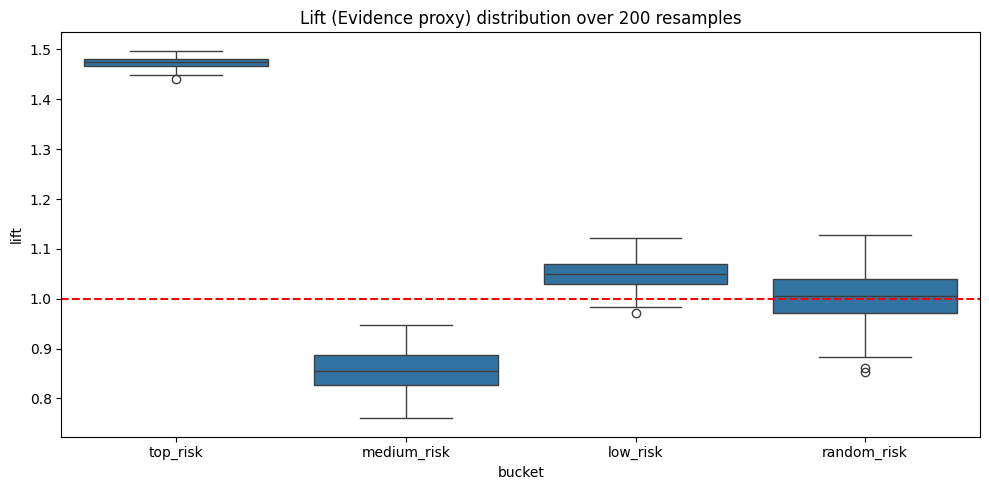

In [30]:
# Visualize lift distribution
plt.figure(figsize=(10, 5))
sns.boxplot(records_df, x='bucket', y='lift')
plt.axhline(y=1, ls='--', color='red')
plt.title(f'Lift (Evidence proxy) distribution over {N_ITR} resamples')
plt.tight_layout()
plt.savefig(results_fig / 'lift_distribution.png', dpi = 300)
plt.show()

**Interpretation:**   
Top-risk flagged items are 1.48 times more likely to actually be anomalies. This number stays consistent across all 200 test runs.   
Medium-risk items are a crap-shoot (sometimes 0.77× useful, sometimes 0.95×).   
Low and random risk buckets are basically the same as picking randomly.   

**Review team can focus on the top-risk bucket and will reliably identify genuine business anomalies**

---
## Final result assembly

In [31]:
# Select final output columns
df = df[
    ['Days for shipping (real)', 'Days for shipment (scheduled)', 
     'Department Name', 'Market', 'order date (DateOrders)',
    'Order Item Discount', 'Order Item Product Price', 
     'Order Item Quantity', 'Order Item Total', 'Order Status',
     'Product Card Id', 'Product Category Id', 'Shipping Mode',
     'iforest', 'anomaly_risk', 'anomaly_rank', 'anomaly_type',
     'deviation_explanation']]

df.to_parquet(data_dir / 'anomaly_df.parquet')

---
# Model save for inference
- Saves trained Isolation Forest models to disk for scoring new data
- Enables production deployment:    
**load models** → **scale new data** → **generate predictions**

In [32]:
# Create supporting model folder
model_dir = results_tab / 'models'
model_dir.mkdir(parents=True, exist_ok=True)

In [33]:
# Save all Isolation Forest models by seeds
for seed in iforest_seeds:
    joblib.dump(iforest_models[seed], model_dir / f'iforest_seed_{seed}.pkl')
print('iforest models saved')

# Save features list for future preprocessing
joblib.dump(model_features, model_dir / 'iforest_model_features.pkl')
print('model_features saved')

# Save the scalar for consistent preprocessing of new data
joblib.dump(scaler, model_dir / 'iforest_scaler.pkl')
print('Scaler for model_features saved')

iforest models saved
model_features saved
Scaler for model_features saved


## Key Takeaway

This notebook shows that not all anomaly detection methods are equally useful for production use.

- Isolation Forest is the strongest candidate because it is relatively stable across random seeds and captures the most business-relevant patterns
- LOF shows weak consistency across neighborhood sizes, which makes it less reliable for deployment
- The baseline score is simple and useful for comparison, but it is not robust enough as a final detection method
- PCA reconstruction error does not detect meaningful anomalies
- The top-ranked anomalies are enriched for real operational issues, so the model can be used to prioritize review and investigation